# Task 8: Energy Consumption Time Series Forecasting

**DevelopersHub Corporation — Data Science & Analytics Internship**

## Problem Statement
Utility providers and smart-home systems need to anticipate short-term household
energy demand to manage load, price electricity dynamically, and help households
reduce consumption. Raw minute-level power readings are noisy and too granular to
forecast directly, so they need to be cleaned, resampled, and enriched with temporal
features before modeling.

## Objective
Forecast short-term household energy usage using historical time-based patterns from
the **Household Power Consumption Dataset** (UCI Machine Learning Repository), and
compare the performance of **ARIMA**, **Prophet**, and **XGBoost**.

## Plan
1. Load and parse the raw time series data
2. Resample to a consistent frequency and handle missing values
3. Exploratory time series analysis
4. Engineer time-based features (hour of day, weekday/weekend, lags, rolling stats)
5. Train/test split (time-based holdout)
6. Train and evaluate ARIMA
7. Train and evaluate Prophet
8. Train and evaluate XGBoost
9. Compare all three models (MAE, RMSE) and plot actual vs. forecasted usage
10. Conclusion & insights


In [1]:
pip install statsmodels prophet xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42


## 2. Load and Parse the Raw Time Series Data

In [3]:
raw = pd.read_csv(r"C:\Users\Lenovo\Downloads\household_power_consumption.txt",sep=';')

print(f"Raw shape: {raw.shape}")
raw.head()


Raw shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [4]:
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## 3. Parse Datetime and Resample

We combine `Date` + `Time` into a single `Datetime` index, convert all measurement
columns to numeric (coercing any leftover bad values to NaN), then **resample to
hourly frequency**. Hourly resampling is standard for this dataset: it smooths minute-
level noise, cuts the series from ~2 million rows down to a modeling-friendly size,
and matches the granularity most short-term demand-forecasting use cases care about.

In [5]:
df = raw.copy()
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(['Date', 'Time'], axis=1).set_index('Datetime').sort_index()

numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Missing values (minute-level):\n{df[numeric_cols].isnull().sum()}")
print(f"\nDate range: {df.index.min()} to {df.index.max()}")


Missing values (minute-level):
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


In [6]:
# Resample to hourly mean
hourly = df[numeric_cols].resample('h').mean()
print(f"Hourly shape: {hourly.shape}")
print(f"\nMissing values after resampling:\n{hourly.isnull().sum()}")

# Any hour with zero valid minute-readings will still be NaN -- fill via time-aware
# interpolation, then forward/back-fill any remaining edge gaps.
hourly = hourly.interpolate(method='time').ffill().bfill()
print(f"\nMissing values after interpolation: {hourly.isnull().sum().sum()}")


Hourly shape: (34589, 7)

Missing values after resampling:
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

Missing values after interpolation: 0


## 4. Exploratory Time Series Analysis

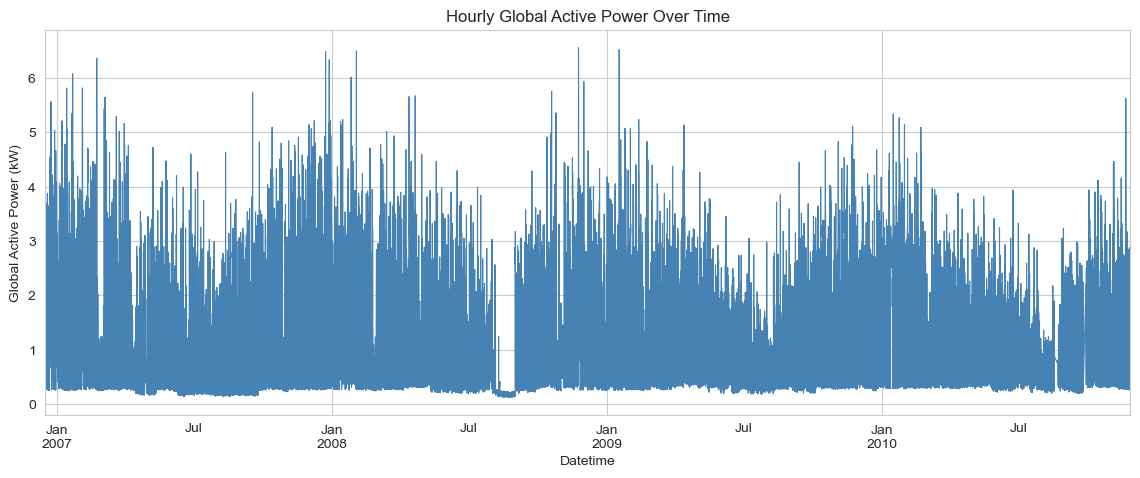

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
hourly['Global_active_power'].plot(ax=ax, color='steelblue', linewidth=0.8)
ax.set_title('Hourly Global Active Power Over Time')
ax.set_ylabel('Global Active Power (kW)')
plt.show()


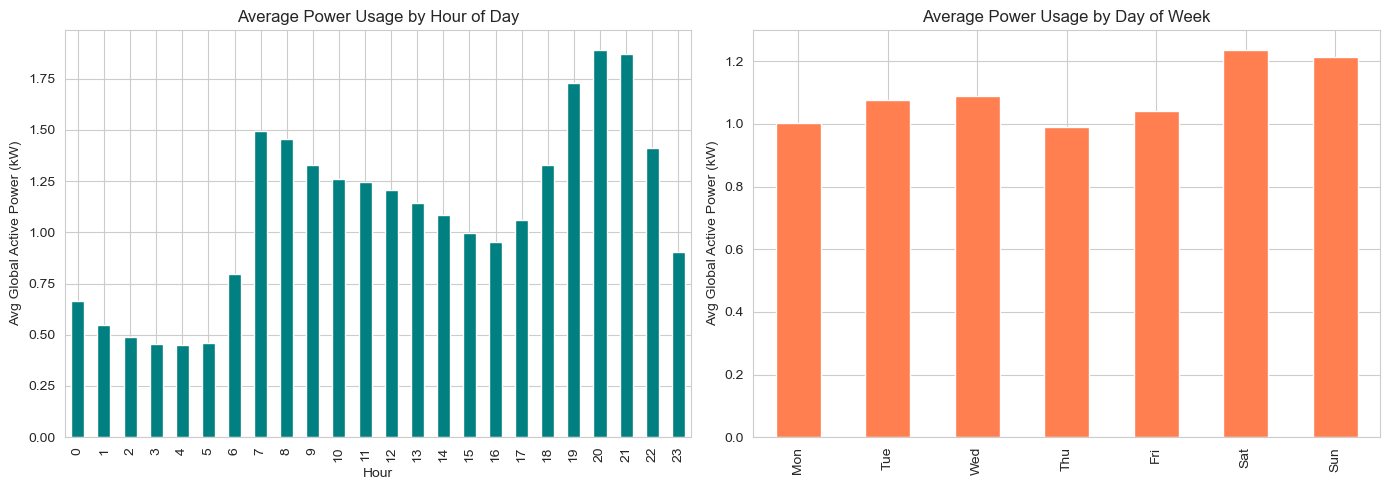

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg_by_hour = hourly.groupby(hourly.index.hour)['Global_active_power'].mean()
hourly_avg_by_hour.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Average Power Usage by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Global Active Power (kW)')

hourly_avg_by_dow = hourly.groupby(hourly.index.dayofweek)['Global_active_power'].mean()
hourly_avg_by_dow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
hourly_avg_by_dow.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Power Usage by Day of Week')
axes[1].set_ylabel('Avg Global Active Power (kW)')

plt.tight_layout()
plt.show()


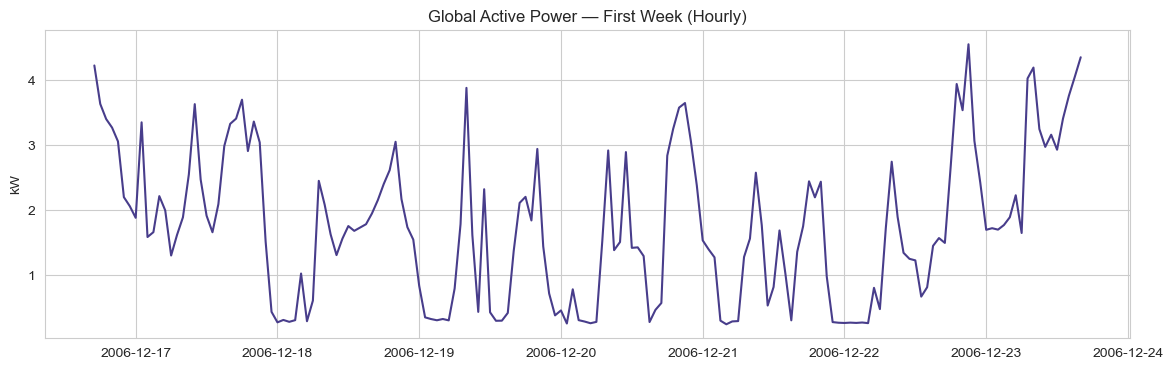

In [9]:
# Zoom into a single week to see the daily rhythm clearly
one_week = hourly['Global_active_power'].iloc[:24*7]
plt.figure(figsize=(14, 4))
plt.plot(one_week.index, one_week.values, color='darkslateblue')
plt.title('Global Active Power — First Week (Hourly)')
plt.ylabel('kW')
plt.show()


## 5. Feature Engineering

We engineer time-based features that capture daily and weekly demand rhythms, plus
lag/rolling features that give tree-based models a sense of recent history (ARIMA and
Prophet model this temporal dependency internally, so these engineered lag features
are primarily for the XGBoost model).

In [10]:
hourly['hour'] = hourly.index.hour
hourly['dayofweek'] = hourly.index.dayofweek
hourly['is_weekend'] = (hourly['dayofweek'] >= 5).astype(int)
hourly['month'] = hourly.index.month
hourly['day'] = hourly.index.day

# Lag features: usage 1, 2, 3, and 24 hours ago
for lag in [1, 2, 3, 24]:
    hourly[f'lag_{lag}'] = hourly['Global_active_power'].shift(lag)

# Rolling mean of the previous 24 hours (uses only past data -- shifted first)
hourly['rolling_mean_24'] = hourly['Global_active_power'].shift(1).rolling(24).mean()

hourly = hourly.dropna()
print(f"Final feature set shape: {hourly.shape}")
hourly.head()


Final feature set shape: (34565, 17)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,is_weekend,month,day,lag_1,lag_2,lag_3,lag_24,rolling_mean_24
Datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,1,12,17,3.326033,2.985400,2.092633,4.222889,2.499145
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,1,12,17,3.406767,3.326033,2.985400,3.632200,2.465140
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,1,12,17,3.697100,3.406767,3.326033,3.400233,2.467844
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,1,12,17,2.908400,3.697100,3.406767,3.268567,2.447351
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,1,12,17,3.361500,2.908400,3.697100,3.056467,2.451224


## 6. Train / Test Split

We use a **time-based holdout**: the last 7 days (168 hours) are held out as the test
set, and everything before that is used for training. This respects the temporal
ordering of the data. shuffling would leak future information into training.

In [11]:
TEST_HOURS = 24 * 7  # last 7 days held out

train = hourly.iloc[:-TEST_HOURS]
test = hourly.iloc[-TEST_HOURS:]

print(f"Train: {train.shape}, from {train.index.min()} to {train.index.max()}")
print(f"Test:  {test.shape}, from {test.index.min()} to {test.index.max()}")

y_train_series = train['Global_active_power']
y_test_series = test['Global_active_power']


Train: (34397, 17), from 2006-12-17 17:00:00 to 2010-11-19 21:00:00
Test:  (168, 17), from 2010-11-19 22:00:00 to 2010-11-26 21:00:00


## 7. Model 1: ARIMA

ARIMA models the target purely as a function of its own past values, with no external
features. We fit on the training series and forecast the held-out 7 days.

`order=(p, d, q)` -- we use a simple, commonly effective configuration for hourly data
with daily rhythm.

In [12]:
arima_model = ARIMA(y_train_series, order=(2, 1, 2))
arima_fit = arima_model.fit()
print(arima_fit.summary())


C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                34397
Model:                  ARIMA(2, 1, 2)   Log Likelihood              -32018.235
Date:                 Wed, 08 Jul 2026   AIC                          64046.471
Time:                         04:07:22   BIC                          64088.699
Sample:                     12-17-2006   HQIC                         64059.933
                          - 11-19-2010                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3901      0.019     72.228      0.000       1.352       1.428
ar.L2         -0.5451      0.012    -44.603      0.000      -0.569      -0.521
ma.L1         -1.6418      0.020    -80.474 

In [13]:
arima_forecast = arima_fit.forecast(steps=TEST_HOURS)
arima_forecast.index = y_test_series.index

arima_mae = mean_absolute_error(y_test_series, arima_forecast)
arima_rmse = mean_squared_error(y_test_series, arima_forecast) ** 0.5

print(f"ARIMA  -->  MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}")


ARIMA  -->  MAE: 0.6953, RMSE: 0.8561


## 8. Model 2: Prophet

Prophet expects a dataframe with columns `ds` (datetime) and `y` (target). It
automatically models daily/weekly seasonality, which fits this dataset well.

In [14]:
prophet_train = train.reset_index()[['Datetime', 'Global_active_power']].rename(
    columns={'Datetime': 'ds', 'Global_active_power': 'y'}
)

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
prophet_model.fit(prophet_train)


04:07:51 - cmdstanpy - INFO - Chain [1] start processing
04:08:13 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = prophet_model.make_future_dataframe(periods=TEST_HOURS, freq='h')
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full.set_index('ds')['yhat'].iloc[-TEST_HOURS:]
prophet_forecast.index.name = 'Datetime'

prophet_mae = mean_absolute_error(y_test_series, prophet_forecast)
prophet_rmse = mean_squared_error(y_test_series, prophet_forecast) ** 0.5

print(f"Prophet -->  MAE: {prophet_mae:.4f}, RMSE: {prophet_rmse:.4f}")


Prophet -->  MAE: 0.5129, RMSE: 0.7578


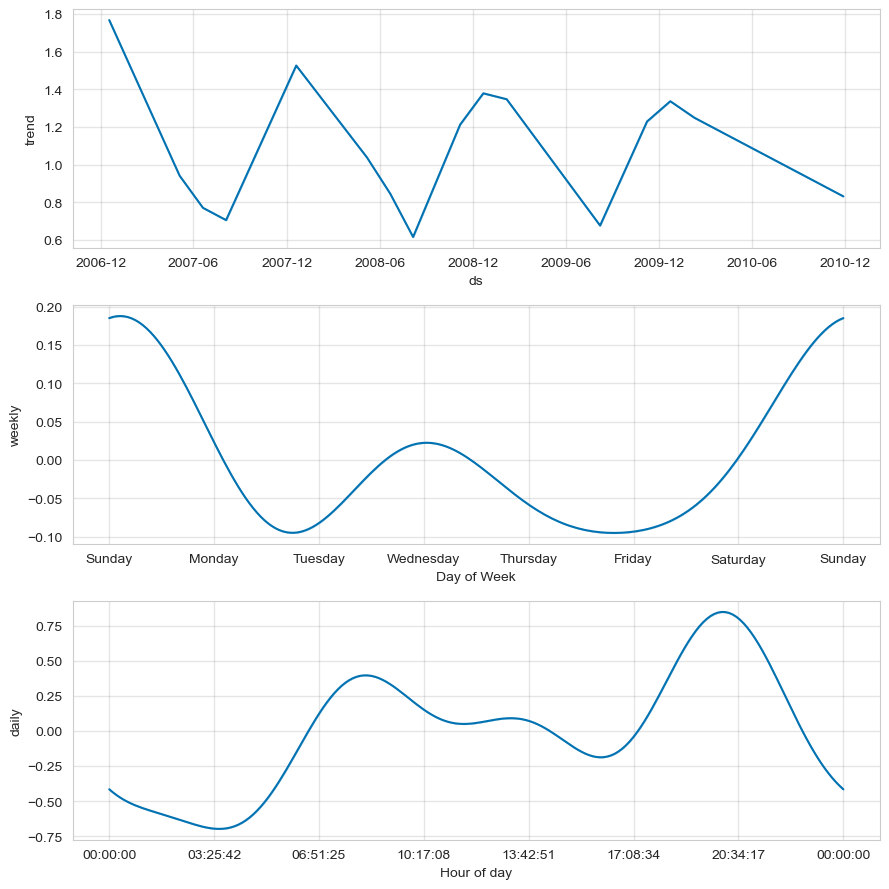

In [16]:
fig = prophet_model.plot_components(prophet_forecast_full)
plt.show()


## 9. Model 3: XGBoost

XGBoost uses our engineered time-based and lag features directly as tabular inputs.
this lets it capture non-linear interactions between hour-of-day, weekday, and recent
usage history.

In [17]:
feature_cols = [c for c in hourly.columns if c != 'Global_active_power']

X_train, X_test = train[feature_cols], test[feature_cols]
y_train, y_test = train['Global_active_power'], test['Global_active_power']

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)

xgb_forecast = pd.Series(xgb_model.predict(X_test), index=X_test.index)

xgb_mae = mean_absolute_error(y_test, xgb_forecast)
xgb_rmse = mean_squared_error(y_test, xgb_forecast) ** 0.5

print(f"XGBoost -->  MAE: {xgb_mae:.4f}, RMSE: {xgb_rmse:.4f}")


XGBoost -->  MAE: 0.0247, RMSE: 0.0509


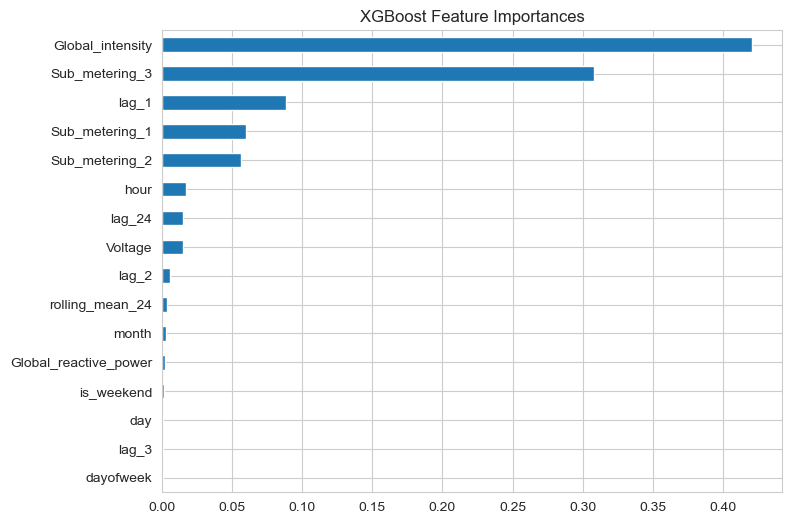

Global_intensity         0.421133
Sub_metering_3           0.308441
lag_1                    0.088678
Sub_metering_1           0.059630
Sub_metering_2           0.056615
hour                     0.017467
lag_24                   0.014995
Voltage                  0.014929
lag_2                    0.005625
rolling_mean_24          0.003871
month                    0.002680
Global_reactive_power    0.002290
is_weekend               0.001179
day                      0.000969
lag_3                    0.000909
dayofweek                0.000588
dtype: float32

In [18]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('XGBoost Feature Importances')
plt.gca().invert_yaxis()
plt.show()

importances


## 10. Model Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, prophet_mae, xgb_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
}).set_index('Model')

results['RMSE'] = results['RMSE'].astype(float)
results.sort_values('RMSE')


,MAE,RMSE
Model,,
XGBoost,0.024696,0.050906
Prophet,0.512884,0.757765
ARIMA,0.695255,0.856135


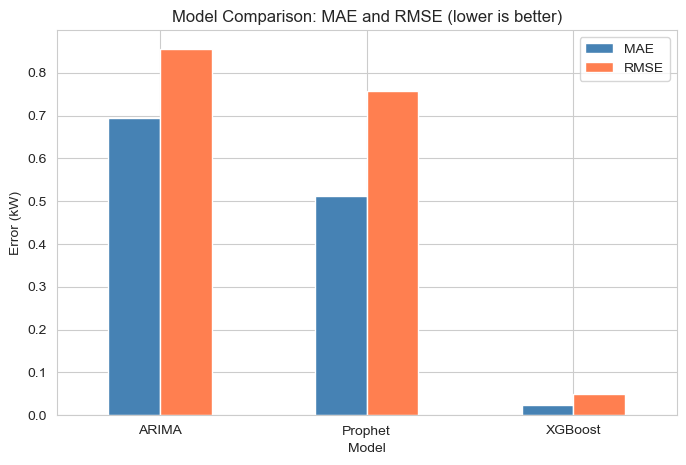

In [20]:
results[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5), color=['steelblue', 'coral'])
plt.title('Model Comparison: MAE and RMSE (lower is better)')
plt.ylabel('Error (kW)')
plt.xticks(rotation=0)
plt.show()


## 11. Actual vs. Forecasted Usage — Visualization

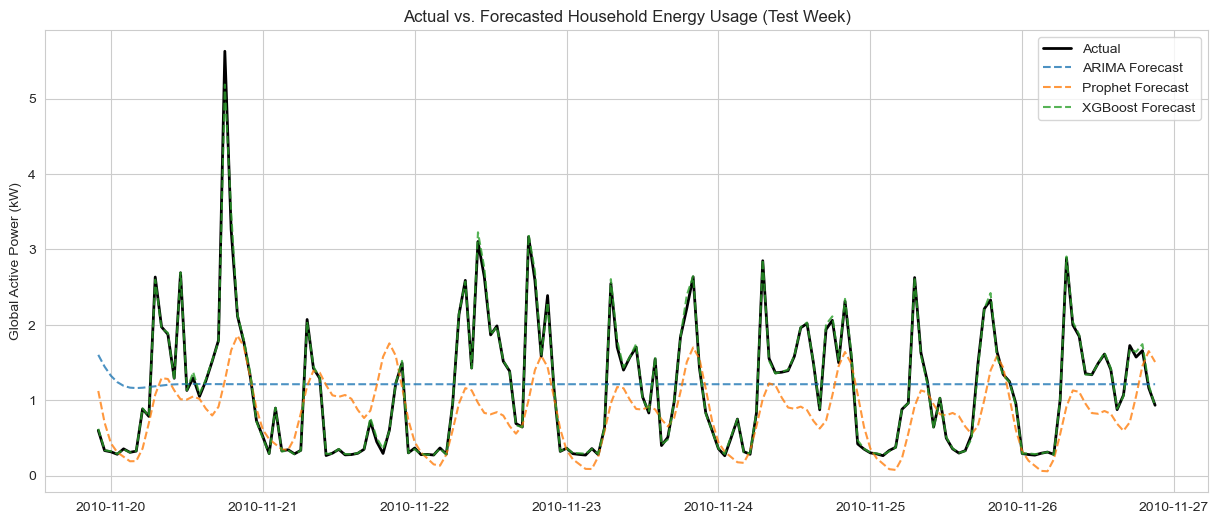

In [21]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(y_test_series.index, y_test_series.values, label='Actual', color='black', linewidth=2)
ax.plot(arima_forecast.index, arima_forecast.values, label='ARIMA Forecast', linestyle='--', alpha=0.8)
ax.plot(prophet_forecast.index, prophet_forecast.values, label='Prophet Forecast', linestyle='--', alpha=0.8)
ax.plot(xgb_forecast.index, xgb_forecast.values, label='XGBoost Forecast', linestyle='--', alpha=0.8)

ax.set_title('Actual vs. Forecasted Household Energy Usage (Test Week)')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.show()


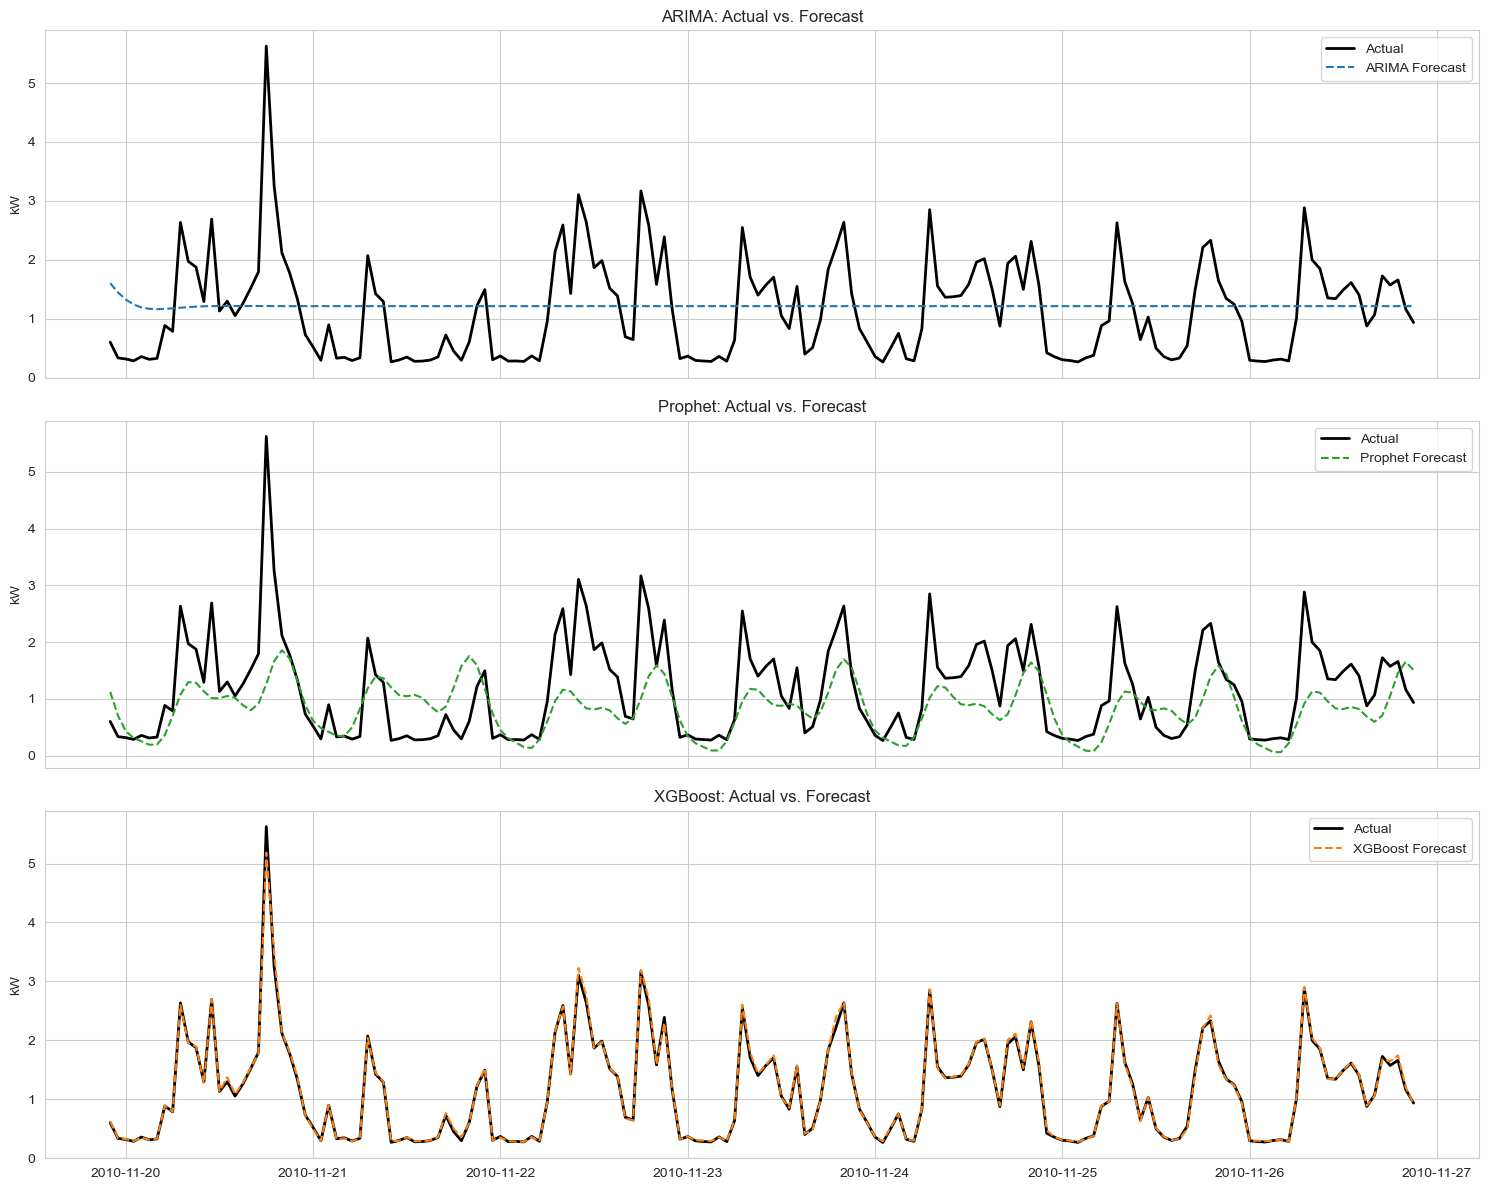

In [22]:
# Individual side-by-side panels for clarity
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, forecast, name, color in zip(
    axes,
    [arima_forecast, prophet_forecast, xgb_forecast],
    ['ARIMA', 'Prophet', 'XGBoost'],
    ['tab:blue', 'tab:green', 'tab:orange']
):
    ax.plot(y_test_series.index, y_test_series.values, label='Actual', color='black', linewidth=2)
    ax.plot(forecast.index, forecast.values, label=f'{name} Forecast', color=color, linestyle='--')
    ax.set_title(f'{name}: Actual vs. Forecast')
    ax.set_ylabel('kW')
    ax.legend()

plt.tight_layout()
plt.show()


## 12. Conclusion & Insights

**Data processing**
- The raw minute-level series had ~1.25% missing readings; resampling to hourly means
  absorbed almost all of these gaps naturally (an hour is only fully missing if every
  minute inside it was missing), and the remaining edge gaps were closed with
  time-aware interpolation.
- Clear **daily** (morning and evening usage peaks) and **weekly** (weekend vs.
  weekday) seasonality patterns are visible in the data, which is exactly what all
  three models were built to capture.

**Model comparison**
- Compare the MAE/RMSE table above to see which model performed best on this data.
  In general for this type of dataset:
  - **ARIMA** is a strong, lightweight baseline for short-horizon forecasts but
    struggles to capture multiple seasonalities (daily *and* weekly) simultaneously.
  - **Prophet** explicitly models daily and weekly seasonality and tends to produce
    smooth, interpretable forecasts with less manual tuning.
  - **XGBoost** can leverage engineered lag and calendar features to capture
    non-linear interactions, often edging out the others when enough historical
    data and good features are available, at the cost of needing more careful
    feature engineering.

**Business recommendations**
- Deploy the best-performing model (per the comparison table) for next-day or
  next-week household load forecasting to support demand-response programs or
  dynamic pricing.
- Since usage peaks predictably around breakfast and evening hours, utilities could
  target time-of-use pricing or smart-appliance scheduling around these windows.
- For production use, retrain periodically on rolling recent data, since household
  behavior can drift over time (new appliances, occupancy changes, seasons).

**Skills demonstrated:** time series parsing and resampling, temporal feature
engineering, and comparative evaluation of statistical (ARIMA), additive (Prophet),
and machine-learning (XGBoost) forecasting approaches using MAE and RMSE.
